# FaceDetector Processing

---

Tahapan ini mencakup pengambilan, pemrosesan dan evaluasi untuk skenario tugas dan istirahat
- Mengambil data dari file npy
- Melakukan pre-processing pada sinyal rPPG dan PPG
- Melakukan extraksi HR dan HRV (SDNN dan RMSSD)
- Evaluasi MAE, RMSE dan PC

In [1]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [2]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [3]:
# def preprocess_rppg(rppg_signal, fs_rppg=35, fs_ppg=64):
#     # Calculate new number of samples
#     duration = len(rppg_signal) / fs_rppg  # 3 minutes in seconds
#     num_samples_new = int(duration * fs_ppg)
    
#     # Method 1: Fourier-based (recommended for periodic signals)
#     # rppg_up = scipy.signal.resample(rppg_signal, num_samples_new)
    
#     # OR Method 2: Cubic spline
#     t_old = np.arange(len(rppg_signal)) / fs_rppg
#     t_new = np.linspace(0, duration, num_samples_new)
#     cs = scipy.interpolate.CubicSpline(t_old, rppg_signal)
#     rppg_up = cs(t_new)
    
#     # Bandpass filter at new rate
#     b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
#     rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)
    
#     # Normalize
#     rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)
    
#     return rppg_filtered

In [4]:
def preprocess_rppg(rppg_signal, fs_rppg=35, fs_ppg=64):
    # Target: exactly 180 seconds at 64 Hz = 11520 samples
    target_duration = 180.0  # seconds
    target_samples = 11520  # Exact target
    
    # Calculate current duration
    current_duration = len(rppg_signal) / fs_rppg
    print(f"Original samples: {len(rppg_signal)}, Current duration: {current_duration:.2f}s")
    
    # Trim to exactly 180 seconds if longer
    if current_duration > target_duration:
        samples_to_keep = int(target_duration * fs_rppg)  # 180 * 35 = 6300 samples
        rppg_trimmed = rppg_signal[:samples_to_keep]
    else:
        rppg_trimmed = rppg_signal
        print(f"No trimming needed, using {len(rppg_trimmed)} samples")
    
    # Cubic spline interpolation with EXACT target samples
    duration_trimmed = len(rppg_trimmed) / fs_rppg
    t_old = np.arange(len(rppg_trimmed)) / fs_rppg
    t_new = np.linspace(0, duration_trimmed, target_samples, endpoint=False)  # endpoint=False is KEY
    cs = scipy.interpolate.CubicSpline(t_old, rppg_trimmed)
    rppg_up = cs(t_new)
    
    print(f"After interpolation: {len(rppg_up)} samples (target: {target_samples})")
    
    # Bandpass filter at new rate
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)
    
    # Normalize
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)
    
    # Final verification
    print(f"Final output: {len(rppg_filtered)} samples")
    assert len(rppg_filtered) == target_samples, f"Length mismatch: got {len(rppg_filtered)}, expected {target_samples}"
    
    return rppg_filtered

In [5]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


Main Methods

---

Opening the npy files for FaceDetector

In [6]:
root_path = "workflow-research/dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=sample_rate_video,
                    preprocessed=rppg_preproc
                )
            )

## Sanity check the pipeline for the result
## Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6300, Current duration: 180.00s
No trimming needed, using 6300 samples
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
After in

Notes:

---

The signal been in the same length and preprocessed

and it's fine to move on to the HR / HRV Extraction

## Evaluasi Performa rPPG
---

Tahapan ini akan mengukur HR / HRV dari rPPG dan PPG

In [7]:
@dataclass
class MetricData:
    subject: str
    task: str
    method: str
    hr: float
    sdnn: float
    rmssd: float


In [8]:
# @dataclass
# class MetricData:
#     subject: str
#     task: str
#     method: str
#     hr: Optional[int]
#     sdnn: Optional[int]
#     rmssd: Optional[int]
#     rejection_rate: Optional[float]  # Add rejection rate
#     n_peaks: Optional[int]  # Number of detected peaks
#     n_valid_rr: Optional[int]  # Number of valid RR intervals


**Formula Perhitungan HR dan HRV**

**Heart Rate (HR):**
$$
HR = \frac{60}{\overline{RR}}
$$
- $\overline{RR}$ = rata-rata interval RR (detik) antar puncak sinyal

**SDNN (Standard Deviation of NN intervals):**
$$
SDNN = \text{std}(RR_{ms})
$$
- $(RR_{ms})$ = interval RR dalam milidetik

**RMSSD (Root Mean Square of Successive Differences):**
$$
RMSSD = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (RR_{ms,i+1} - RR_{ms,i})^2}
$$
- $(RR_{ms,i})$ = interval RR ke-i dalam milidetik
- $(N)$ = jumlah interval RR valid

**Langkah:**
1. Deteksi puncak sinyal (peak detection)
2. Hitung interval RR antar puncak: $(RR = \frac{\Delta \text{peak}}{fs})$
3. Bersihkan RR di luar rentang 0.3–2.0 detik
4. Konversi RR ke milidetik: $(RR_{ms} = RR \times 1000)$
5. Hitung HR, SDNN, RMSSD dengan rumus

In [9]:
# ## Define the method to compute the metrics
# ## This method will takes any signal (rPPG, PPG) 
# # and it's sampling rate to get the HR and HRv
# def compute_metrics(signal, fs):
#     ## Compute the HR
#     peaks , _ = scipy.signal.find_peaks(signal, prominence=0.5)
#     # peaks , _ = scipy.signal.find_peaks(signal)

#     ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
#     rr = np.diff(peaks) / fs  # Convert to unit seconds

#     ## Clean the RR
#     rr = np.asarray(rr, dtype=float)

#     rr_intervals = rr[( rr >= 0.4 ) & (rr <= 1.2)] 

#     ## Calculating the HR
#     hr = int(60 / np.mean(rr_intervals))
    
#     ## Converting RR interval for milis for HRV analysis
#     rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds

#     ## Calculating the HRV (SDNN, RMSSD)
#     ## Casting to Int for easier interpretation
#     sdnn = int(np.std(rr_intervals_ms))
#     rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))

#     return hr, sdnn, rmssd

In [10]:
import numpy as np
import scipy.signal

def compute_metrics(signal, fs, method, subject, segment_len=25, seg_threshold=0.3, delta_threshold=0.5, ):
    """
    Compute HR and HRV metrics (SDNN, RMSSD) from rPPG or PPG signal.
    
    Parameters:
        signal : 1D array
            Raw PPG or rPPG signal.
        fs : float
            Sampling rate (Hz)
        segment_len : int
            Number of beats per segment for relative filtering.
        seg_threshold : float
            Fractional deviation allowed from segment mean (e.g., 0.3 = ±30%).
        delta_threshold : float
            Max allowed difference between consecutive RR intervals (s).
    
    Returns:
        hr : int
            Mean heart rate in bpm
        sdnn : int
            SDNN in ms
        rmssd : int
            RMSSD in ms
    """

    # 1. Detect peaks
    peaks, _ = scipy.signal.find_peaks(signal, prominence=0.5)
    
    if len(peaks) < 2:
        return np.nan, np.nan, np.nan  # Not enough peaks
    
    # 2. Compute RR intervals (s)
    rr = np.diff(peaks) / fs
    rr = np.asarray(rr, dtype=float)
    
    rr_intervals = rr[(rr >= 0.5) & (rr <= 1.0)]
    if method == "PPG" :
        print(f"RR Intervals {subject}: ", rr_intervals)

    # 3. Hard physiologic filter
    rr = rr[(rr >= 0.3) & (rr <= 2.0)]
    if len(rr) < 2:
        return np.nan, np.nan, np.nan
    
    # 4. Segment-based ±30% filtering
    clean_rr = []
    num_segments = len(rr) // segment_len
    for i in range(num_segments):
        seg = rr[i*segment_len:(i+1)*segment_len]
        mean_seg = np.mean(seg)
        lower = mean_seg * (1 - seg_threshold)
        upper = mean_seg * (1 + seg_threshold)
        clean_seg = seg[(seg >= lower) & (seg <= upper)]
        clean_rr.extend(clean_seg)
    
    rr_final = np.array(clean_rr)
    if method == "PPG" :
        print(f"RR Final {subject}: ", rr_final)
    
    # # Include leftover segment if any
    # remainder = rr[num_segments*segment_len:]
    # if len(remainder) > 0:
    #     mean_seg = np.mean(remainder)
    #     lower = mean_seg * (1 - seg_threshold)
    #     upper = mean_seg * (1 + seg_threshold)
    #     clean_rr.extend(remainder[(remainder >= lower) & (remainder <= upper)])
    
    
    # if len(clean_rr) < 2:
    #     return np.nan, np.nan, np.nan

    # # 5. Adjacency check (ΔRR)
    # delta_rr = np.abs(np.diff(clean_rr))
    # artifact_idx = np.where(delta_rr > delta_threshold)[0] + 1  # flag jumps > threshold

    # # Interpolation to fix flagged RR intervals
    # good_idx = np.array([i for i in range(len(clean_rr)) if i not in artifact_idx])
    # if len(good_idx) < 2:  # Not enough good points to interpolate
    #     rr_final = clean_rr
    # else:
    #     rr_final = np.interp(np.arange(len(clean_rr)), good_idx, clean_rr[good_idx])
    
    # 6. Compute HR
    hr = int(60 / np.mean(rr_final))
    
    # 7. Convert to ms for HRV
    rr_ms = rr_final * 1000
    
    # 8. Compute HRV metrics
    sdnn = int(np.std(rr_ms))
    rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_ms)))))
    
    return hr, sdnn, rmssd


In [11]:
# def compute_metrics(signal, fs, min_hr=60, max_hr=120):
#     """
#     Compute HR and HRV metrics with physiological filtering.
    
#     Parameters:
#     - signal: Input signal (rPPG or PPG)
#     - fs: Sampling frequency (Hz)
#     - min_hr: Minimum physiological HR (default: 60 BPM)
#     - max_hr: Maximum physiological HR (default: 120 BPM)
    
#     Returns:
#     - hr: Heart rate (BPM)
#     - sdnn: Standard deviation of NN intervals (ms)
#     - rmssd: Root mean square of successive differences (ms)
#     - rejection_rate: Percentage of rejected RR intervals
#     - n_peaks: Number of detected peaks
#     - n_valid_rr: Number of valid RR intervals after filtering
#     """
    
#     ## Compute the peaks
#     peaks, _ = scipy.signal.find_peaks(signal, prominence=0.5)
#     n_peaks = len(peaks)
    
#     # Check if enough peaks detected
#     if n_peaks < 2:
#         return None, None, None, 100.0, n_peaks, 0
    
#     ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
#     rr = np.diff(peaks) / fs  # Convert to unit seconds
    
#     ## Clean the RR
#     rr = np.asarray(rr, dtype=float)
#     n_total_rr = len(rr)
    
#     ## Convert HR bounds to RR interval bounds
#     # rr_max = 60 / min_hr  # 60 BPM -> 1.0s
#     # rr_min = 60 / max_hr  # 120 BPM -> 0.5s
#     # rr_intervals = rr[(rr >= rr_min) & (rr <= rr_max)]
    
#     ## Filter physiologically plausible RR intervals
#     rr_intervals = rr[(rr >= 0.5) & (rr <= 1.0)]
#     print(rr_intervals)
#     n_valid_rr = len(rr_intervals)
    
#     ## Calculate rejection rate
#     rejection_rate = 100 * (1 - n_valid_rr / n_total_rr) if n_total_rr > 0 else 100.0
    
#     ## Check if enough valid intervals remain (need at least 3 for meaningful HRV)
#     if n_valid_rr < 3:
#         return None, None, None, rejection_rate, n_peaks, n_valid_rr
    
#     ## Calculating the HR
#     hr = int(60 / np.mean(rr_intervals))
    
#     ## Converting RR interval to milliseconds for HRV analysis
#     rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds
    
#     ## Calculating the HRV (SDNN, RMSSD)
#     ## Casting to Int for easier interpretation
#     sdnn = int(np.std(rr_intervals_ms))
#     rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))
    
#     return hr, sdnn, rmssd, rejection_rate, n_peaks, n_valid_rr


**Create a Header Template for HR, HRV**

---

Membuat header template agar tabel lebih padat dan bisa memuat banyak informasi, akan ada 3 tabel (HR, SDNN, RMSSD), dikelompokan berdasarkan 
- Tipe skenario
- Metode pengukuran data

In [12]:
arrays = [
    [""] + ["Rest"]*6 + ["Task"]*6,
    ["Subject", "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM",
     "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
]


columns = pd.MultiIndex.from_arrays(arrays)

In [13]:
all_metrics = []

for sig in all_signals:
    ## Semua sinyal di resample ke 64 Hz
    hr, sdnn, rmssd = compute_metrics(sig.preprocessed, 64, sig.method, sig.subject) 
    all_metrics.append(MetricData(sig.subject, sig.task, sig.method, hr, sdnn, rmssd))


RR Intervals s41:  [0.625    0.59375  0.59375  0.609375 0.609375 0.625    0.65625  0.734375
 0.6875   0.59375  0.578125 0.546875 0.5625   0.578125 0.53125  0.53125
 0.65625  0.625    0.625    0.578125 0.578125 0.5625   0.546875 0.53125
 0.53125  0.53125  0.5625   0.578125 0.6875   0.6875   0.6875   0.671875
 0.609375 0.609375 0.59375  0.59375  0.625    0.6875   0.6875   0.6875
 0.671875 0.625    0.5625   0.5625   0.5625   0.609375 0.59375  0.59375
 0.578125 0.59375  0.671875 0.671875 0.609375 0.578125 0.5625   0.59375
 0.625    0.578125 0.5625   0.5625   0.59375  0.640625 0.703125 0.671875
 0.65625  0.65625  0.6875   0.6875   0.65625  0.640625 0.640625 0.609375
 0.625    0.625    0.609375 0.703125 0.65625  0.625    0.609375 0.625
 0.625    0.609375 0.578125 0.5625   0.59375  0.578125 0.609375 0.59375
 0.546875 0.59375  0.609375 0.578125 0.546875 0.625    0.5625   0.65625
 0.65625  0.578125 0.703125 0.5625   0.640625 0.53125  0.671875 0.65625
 0.703125 0.515625 0.609375 0.640625 0.59375

In [14]:
# ## Process all signals
# all_metrics = []

# for sig in all_signals:
#     ## Semua sinyal di resample ke 64 Hz
#     hr, sdnn, rmssd, rejection_rate, n_peaks, n_valid_rr = compute_metrics(sig.preprocessed, 64)
    
#     all_metrics.append(MetricData(
#         subject=sig.subject,
#         task=sig.task,
#         method=sig.method,
#         hr=hr,
#         sdnn=sdnn,
#         rmssd=rmssd,
#         rejection_rate=rejection_rate,
#         n_peaks=n_peaks,
#         n_valid_rr=n_valid_rr
#     ))


In [15]:
df_metrics = pd.DataFrame([{
    "Subject": metrics.subject,
    "Task": metrics.task,  # Keep original values first
    "Method": metrics.method,
    "HR": metrics.hr,
    "SDNN": metrics.sdnn,
    "RMSSD": metrics.rmssd
} for metrics in all_metrics])

# Then remap the Task column
task_mapping = {"T1": "Istirahat", "T3": "Tugas Mental"}
df_metrics["Task"] = df_metrics["Task"].map(task_mapping)

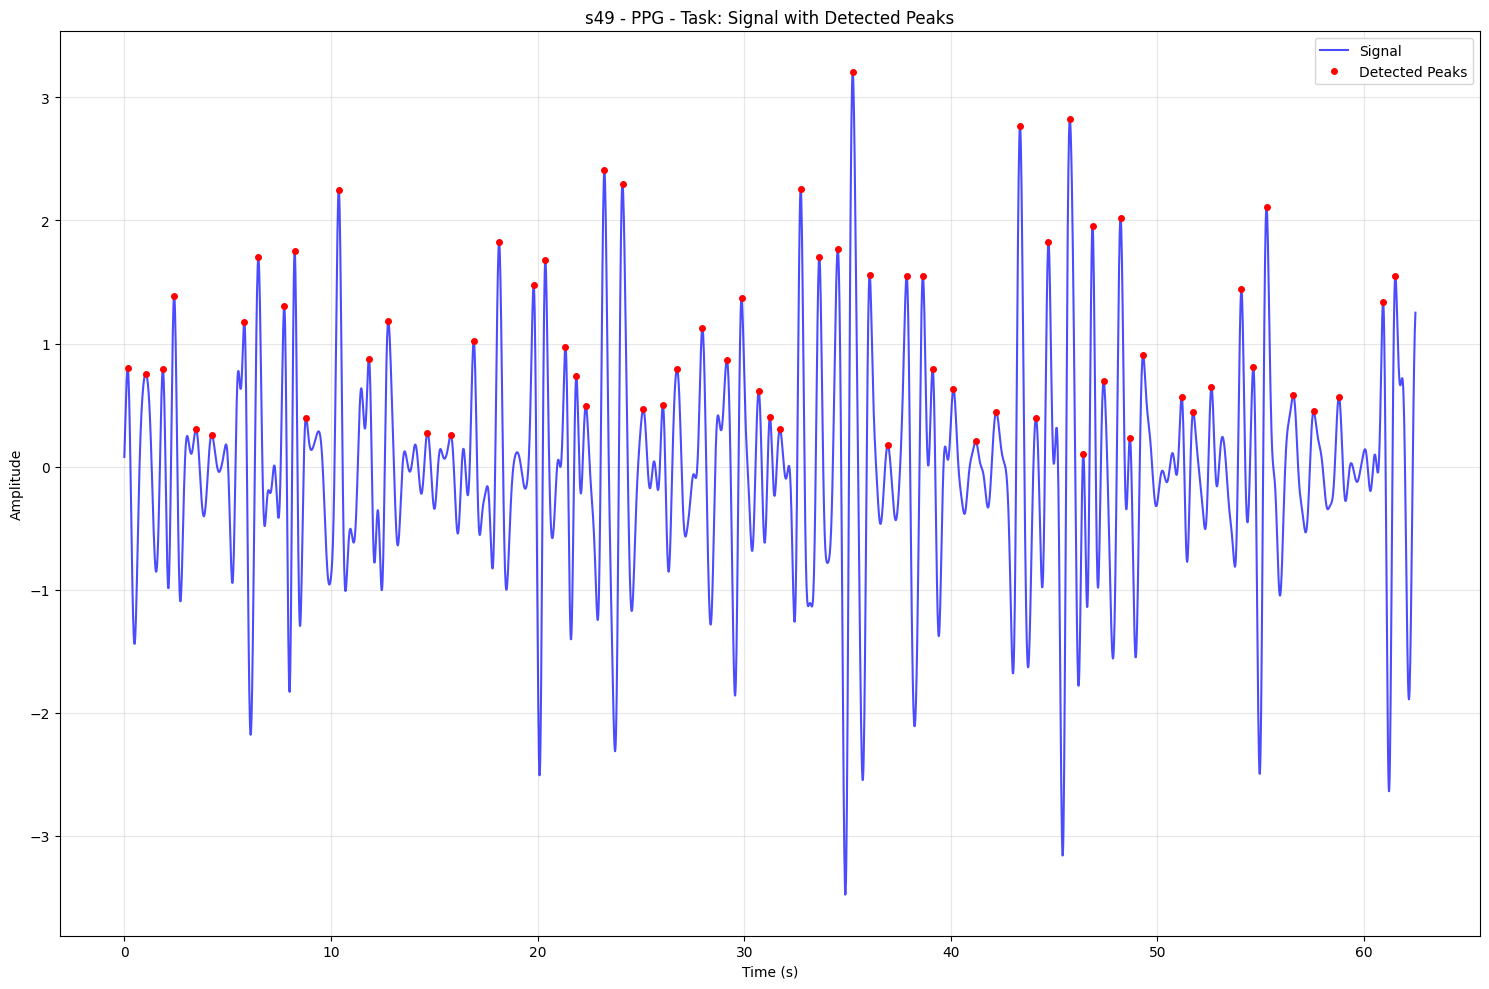


=== s49 - PPG - Task ===
Total peaks detected: 67
Total RR intervals: 66
Valid RR intervals: 65 (98.5%)
Rejected (< 0.5s): 5 (7.6%)
Rejected (> 1.0s): 21 (31.8%)
RR range: 0.453 - 2.141 seconds
Mean valid RR: 0.911 ± 0.345 seconds


In [44]:
## 1. Visualize some signals to see what's going on
import matplotlib.pyplot as plt

def diagnose_signal(signal, fs, subject, method, task):
    """
    Visualize signal with detected peaks and rejected RR intervals
    """
    # Cut the signal 
    signal = signal[4750:8750]
    peaks, properties = scipy.signal.find_peaks(signal, prominence=0.5)
    rr = np.diff(peaks) / fs
    
    # Identify valid and invalid RR intervals
    valid_mask = (rr >= 0.3) & (rr <= 2.0)
    invalid_mask = ~valid_mask

    
    fig, axes = plt.subplots(1, 1, figsize=(15, 10))
    
    # Plot 1: Full signal with peaks
    ax = axes
    time = np.arange(len(signal)) / fs
    ax.plot(time, signal, 'b-', alpha=0.7, label='Signal')
    ax.plot(peaks / fs, signal[peaks], 'ro', markersize=4, label='Detected Peaks')
    ax.set_title(f'{subject} - {method} - {task}: Signal with Detected Peaks')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: RR intervals
    # ax = axes[1]
    # rr_time = peaks[1:] / fs
    # ax.plot(rr_time[valid_mask], rr[valid_mask], 'go', label='Valid RR', markersize=6)
    # ax.plot(rr_time[invalid_mask], rr[invalid_mask], 'rx', label='Rejected RR', markersize=8)
    # ax.axhline(y=0.5, color='orange', linestyle='--', label='Min (60 BPM)')
    # ax.axhline(y=1.0, color='red', linestyle='--', label='Max (120 BPM)')
    # ax.set_title(f'RR Intervals (Rejection Rate: {100 * invalid_mask.sum() / len(rr):.1f}%)')
    # ax.set_xlabel('Time (s)')
    # ax.set_ylabel('RR Interval (s)')
    # ax.legend()
    # ax.grid(True, alpha=0.3)
    
    # Plot 3: Histogram of RR intervals
    # ax = axes[2]
    # ax.hist(rr[valid_mask], bins=30, alpha=0.7, color='green', label='Valid', edgecolor='black')
    # ax.hist(rr[invalid_mask], bins=30, alpha=0.7, color='red', label='Rejected', edgecolor='black')
    # ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=2)
    # ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2)
    # ax.set_title('Distribution of RR Intervals')
    # ax.set_xlabel('RR Interval (s)')
    # ax.set_ylabel('Count')
    # ax.legend()
    # ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(f'diagnosis_{subject}_{method}_{task}.png', dpi=150)
    plt.show()
    
    # Print statistics
    print(f"\n=== {subject} - {method} - {task} ===")
    print(f"Total peaks detected: {len(peaks)}")
    print(f"Total RR intervals: {len(rr)}")
    print(f"Valid RR intervals: {valid_mask.sum()} ({100*valid_mask.sum()/len(rr):.1f}%)")
    print(f"Rejected (< 0.5s): {(rr < 0.5).sum()} ({100*(rr < 0.5).sum()/len(rr):.1f}%)")
    print(f"Rejected (> 1.0s): {(rr > 1.0).sum()} ({100*(rr > 1.0).sum()/len(rr):.1f}%)")
    print(f"RR range: {rr.min():.3f} - {rr.max():.3f} seconds")
    print(f"Mean valid RR: {rr[valid_mask].mean():.3f} ± {rr[valid_mask].std():.3f} seconds")

## Example usage: Check PPG and GREEN for one subject
# Find a signal with high rejection
high_rejection_ppg = [sig for sig in all_signals 
                      if sig.method == 'PPG' and sig.task == 'T3'][0]
high_rejection_ppg2 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][7]
high_rejection_ppg3 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][2]
high_rejection_ppg4 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][3]
high_rejection_ppg5 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][4]
high_rejection_ppg6 = [sig for sig in all_signals 
                      if sig.method == 'PPG' and sig.task == 'T3'][5]
high_rejection_ppg7 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][6]
high_rejection_ppg8 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][7]
high_rejection_ppg9 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][8]
high_rejection_ppg10 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][9]
high_rejection_ppg11 = [sig for sig in all_signals 
                      if sig.method == 'PPG' and sig.task == 'T3'][10]
high_rejection_ppg12 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][11]
high_rejection_ppg13 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][12]
high_rejection_ppg14 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][13]
high_rejection_ppg15 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][14]
high_rejection_ppg16 = [sig for sig in all_signals 
                        if sig.method == 'PPG' and sig.task == 'T3'][15]

diagnose_signal(high_rejection_ppg9.preprocessed, 64, 
                high_rejection_ppg9.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg2.preprocessed, 64, 
#                 high_rejection_ppg2.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg3.preprocessed, 64, 
#                 high_rejection_ppg3.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg4.preprocessed, 64,  
#                 high_rejection_ppg4.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg5.preprocessed, 64,  
#                 high_rejection_ppg5.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg6.preprocessed, 64,  
#                 high_rejection_ppg6.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg7.preprocessed, 64,  
#                 high_rejection_ppg7.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg8.preprocessed, 64,  
#                 high_rejection_ppg8.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg9.preprocessed, 64,  
#                 high_rejection_ppg9.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg10.preprocessed, 64,  
#                 high_rejection_ppg10.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg11.preprocessed, 64,  
#                 high_rejection_ppg11.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg12.preprocessed, 64,  
#                 high_rejection_ppg12.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg13.preprocessed, 64,  
#                 high_rejection_ppg13.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg14.preprocessed, 64,  
#                 high_rejection_ppg14.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg15.preprocessed, 64,
#                 high_rejection_ppg15.subject, 'PPG', 'Task')
# diagnose_signal(high_rejection_ppg16.preprocessed, 64,
#                 high_rejection_ppg16.subject, 'PPG', 'Task')

#### Ekstraksi HR

---

In [17]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Istirahat' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Tugas Mental' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_hr = pd.DataFrame(rows, columns=columns)
df_hr

Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   97   97    95   96   96    97   81  101    79  100  100   102
1      s42   70   70    74   70   70    70   86   93    75   85   85    89
2      s43   95   95    93   94   94    94   88   92    70   88   89    92
3      s44   62   65    64   61   61    66   65   65    65   63   64    68
4      s45   77   77    75   76   76    78   83   84    71   81   81    83
5      s46   74   74    74   74   74    74   90   89    89   88   88    90
6      s47   77   77    75   77   77    78   83   93    63   91   90    92
7      s48   68   71    68   71   71    71   81   83    71   79   79    84
8      s49  101  101    96  101  101   101   72   94    78   89   89    93
9      s50  103  102    98  102  102   102  105  104    88  104  104   104
10     s51   62   62    64   62   62    62   73   74    60   72   72    75
11     s52   78   90    88   90   90    89   78   88    77   87   87    88
12     s53   64   85    83   85   85    85   66   75    75   73   73    76
13     s54   91   93    87   92   92    93   93   93    78   89   89    93
14     s55   93   95    66   93   93    94   87   86    68   84   84    87
15     s56   73   85    70   82   82    84   80   83    78   81   81    86

## Observasi Fisiologis HR
We use how does the task induced can affect the HR

In [18]:
# build grouped stats
grouped = df_metrics.groupby(['Task','Method']).agg({
    'HR':   ['mean','std'],
    'SDNN': ['mean','std'],
    'RMSSD':['mean','std']
})
# flatten column names
grouped.columns = [f"{m}_{stat}" for m,stat in grouped.columns]
grouped = grouped.reset_index()

# build formatted table: MultiIndex rows (Metric, Method) and columns per Task with "mean ± sd"
metrics = ['HR','SDNN','RMSSD']
methods = grouped['Method'].unique()
tasks = grouped['Task'].unique()

rows = []
for metric in metrics:
    for method in methods:
        row = {'Metric': metric, 'Method': method}
        for task in tasks:
            sel = grouped[(grouped['Task']==task) & (grouped['Method']==method)]
            if not sel.empty:
                mean = sel[f'{metric}_mean'].values[0]
                sd   = sel[f'{metric}_std'].values[0]
                row[task] = f"{mean:.2f} ± {sd:.2f}"
            else:
                row[task] = None
        rows.append(row)

df_summary = pd.DataFrame(rows).set_index(['Metric','Method'])
df_summary

Istirahat    Tugas Mental
Metric Method                                
HR     CHROM    83.62 ± 12.73    87.62 ± 9.29
       GREEN    79.38 ± 12.01    74.06 ± 8.05
       LGI      82.88 ± 13.20   84.62 ± 10.13
       OMIT     82.88 ± 13.20    84.69 ± 9.98
       POS      83.69 ± 13.04   87.31 ± 10.03
       PPG      80.31 ± 14.21   81.94 ± 10.14
SDNN   CHROM    89.38 ± 33.74  107.31 ± 24.29
       GREEN   120.69 ± 33.58  154.25 ± 18.46
       LGI      77.56 ± 26.35  104.06 ± 17.90
       OMIT     77.44 ± 26.35  105.19 ± 19.54
       POS      74.62 ± 32.40   96.38 ± 20.63
       PPG      87.19 ± 48.24  112.69 ± 36.22
RMSSD  CHROM   114.56 ± 42.05  142.75 ± 30.40
       GREEN   151.50 ± 33.56  190.06 ± 20.73
       LGI      87.50 ± 23.63  137.69 ± 23.94
       OMIT     87.12 ± 23.17  138.25 ± 25.23
       POS      78.62 ± 29.30  122.44 ± 25.22
       PPG      90.25 ± 54.80  139.00 ± 46.32

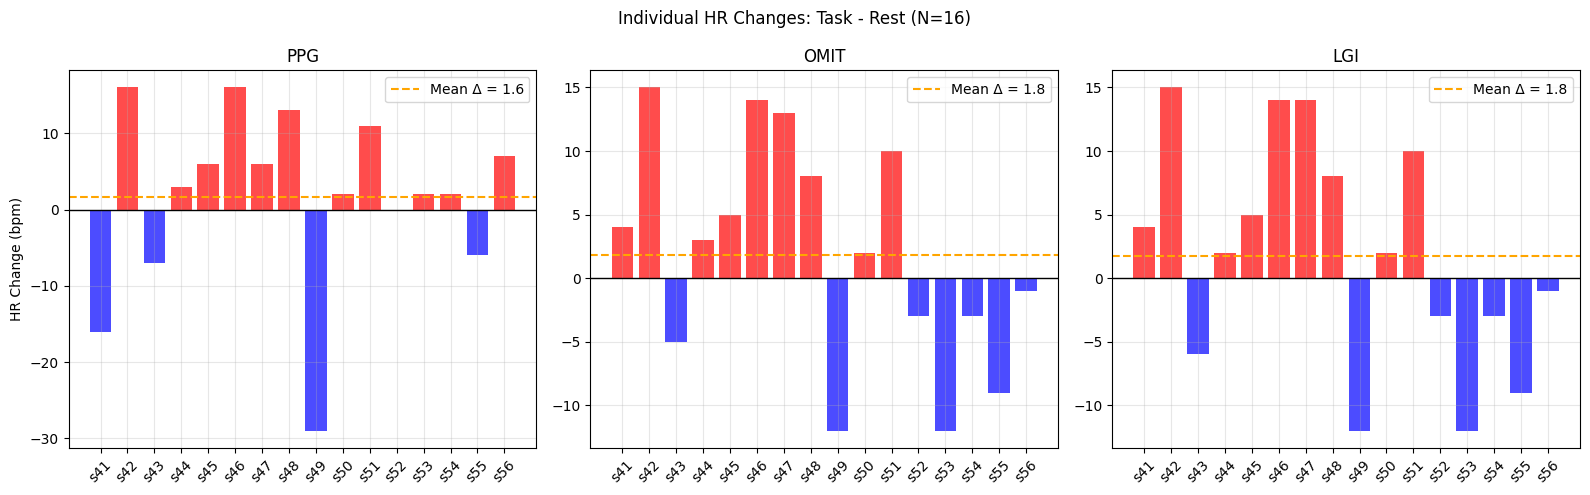

In [19]:
methods = ["PPG", "OMIT", "LGI"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, method in enumerate(methods):
    pivot = df_metrics[df_metrics["Method"]==method].pivot(index="Subject", columns="Task", values="HR")
    delta = pivot["Tugas Mental"] - pivot["Istirahat"]
    
    colors = ['red' if x > 0 else 'blue' for x in delta.values]
    bars = axes[i].bar(range(len(delta)), delta.values, color=colors, alpha=0.7)
    
    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].axhline(delta.mean(), color="orange", linestyle="--", 
                   label=f"Mean Δ = {delta.mean():.1f}")
    
    axes[i].set_xticks(range(len(delta)))
    axes[i].set_xticklabels(delta.index, rotation=45)
    axes[i].set_ylabel("HR Change (bpm)" if i==0 else "")
    axes[i].set_title(f"{method}")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Individual HR Changes: Task - Rest (N=16)")
plt.tight_layout()
plt.show()

### HRV Metrics

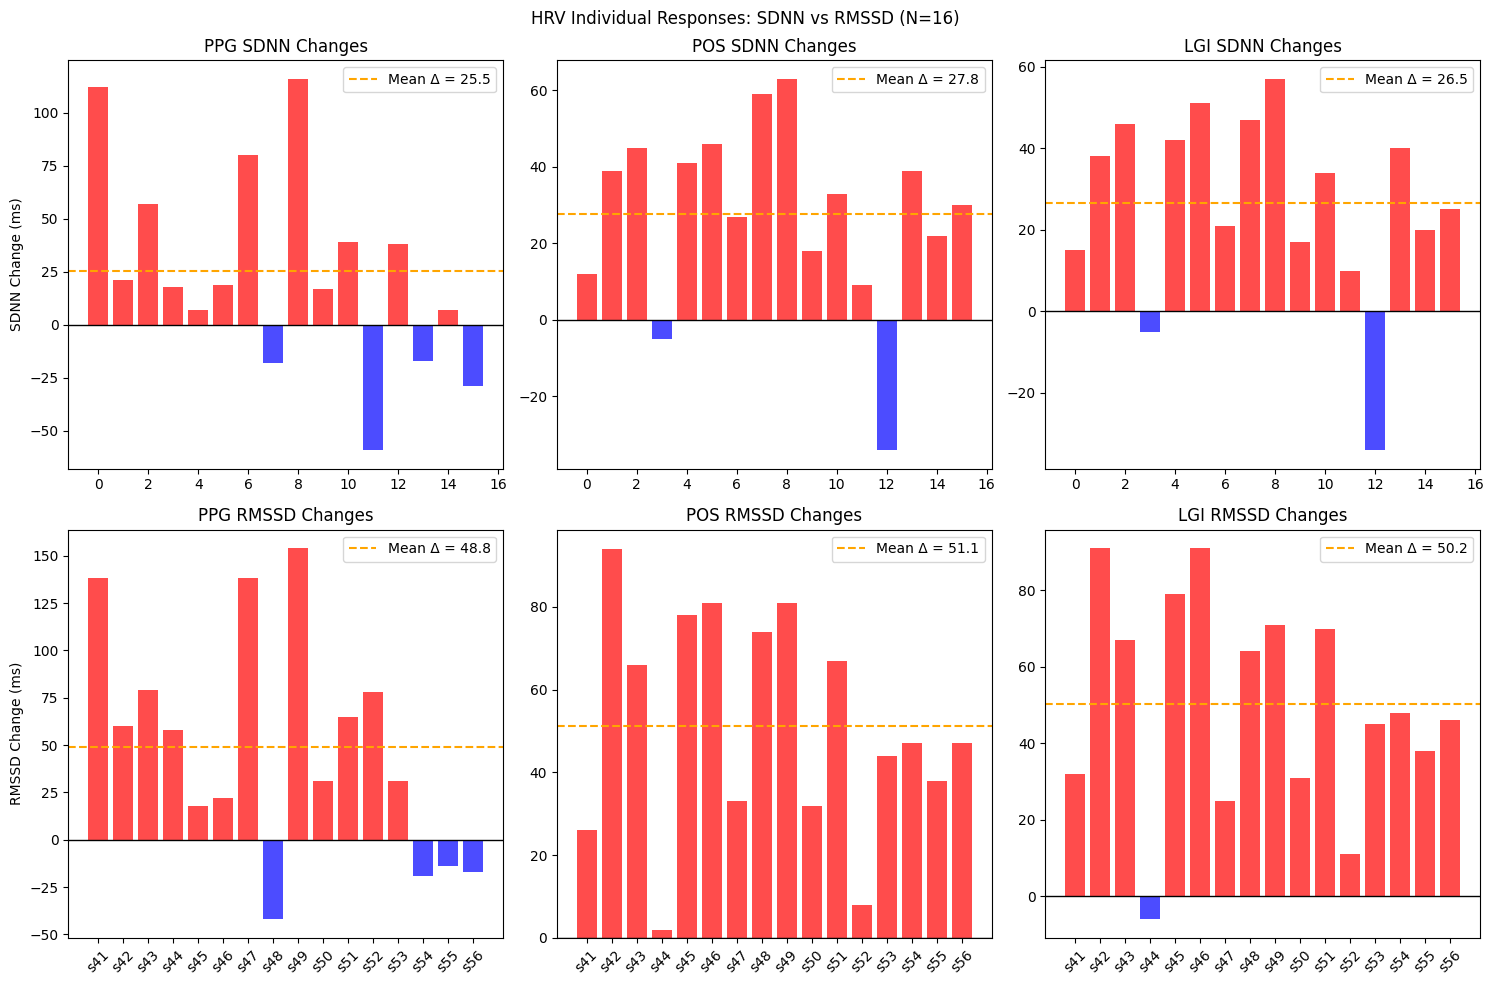

In [20]:
# Compare SDNN and RMSSD individual responses

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# PPG Ground Truth
for row, metric in enumerate(["SDNN", "RMSSD"]):
    pivot = df_metrics[df_metrics["Method"]=="PPG"].pivot(index="Subject", columns="Task", values=metric)
    delta = pivot["Tugas Mental"] - pivot["Istirahat"]
    
    # Individual delta bars
    colors = ['red' if x > 0 else 'blue' for x in delta.values]
    axes[row, 0].bar(range(len(delta)), delta.values, color=colors, alpha=0.7)
    axes[row, 0].axhline(0, color="black", linewidth=1)
    axes[row, 0].axhline(delta.mean(), color="orange", linestyle="--", 
                        label=f"Mean Δ = {delta.mean():.1f}")
    axes[row, 0].set_title(f"PPG {metric} Changes")
    axes[row, 0].set_ylabel(f"{metric} Change (ms)")
    axes[row, 0].legend()
    
    # POS comparison
    pivot_pos = df_metrics[df_metrics["Method"]=="OMIT"].pivot(index="Subject", columns="Task", values=metric)
    delta_pos = pivot_pos["Tugas Mental"] - pivot_pos["Istirahat"]
    
    colors_pos = ['red' if x > 0 else 'blue' for x in delta_pos.values]
    axes[row, 1].bar(range(len(delta_pos)), delta_pos.values, color=colors_pos, alpha=0.7)
    axes[row, 1].axhline(0, color="black", linewidth=1)
    axes[row, 1].axhline(delta_pos.mean(), color="orange", linestyle="--", 
                        label=f"Mean Δ = {delta_pos.mean():.1f}")
    axes[row, 1].set_title(f"POS {metric} Changes")
    axes[row, 1].legend()

    # LGI comparison
    pivot_lgi = df_metrics[df_metrics["Method"]=="LGI"].pivot(index="Subject", columns="Task", values=metric)
    delta_lgi = pivot_lgi["Tugas Mental"] - pivot_lgi["Istirahat"]

    colors_lgi = ['red' if x > 0 else 'blue' for x in delta_lgi.values]
    axes[row, 2].bar(range(len(delta_lgi)), delta_lgi.values, color=colors_lgi, alpha=0.7)
    axes[row, 2].axhline(0, color="black", linewidth=1)
    axes[row, 2].axhline(delta_lgi.mean(), color="orange", linestyle="--", 
                        label=f"Mean Δ = {delta_lgi.mean():.1f}")
    axes[row, 2].set_title(f"LGI {metric} Changes")
    axes[row, 2].legend()

# Subject labels for bottom row
for ax in axes[1, :]:
    ax.set_xticks(range(len(delta)))
    ax.set_xticklabels(delta.index, rotation=45)

plt.suptitle("HRV Individual Responses: SDNN vs RMSSD (N=16)")
plt.tight_layout()
plt.show()

#### Evaluasi HR (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai HR antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran HR dari rPPG dan PPG.

In [21]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_hr[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_hr[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_hr = pd.DataFrame(eval_results)
print("HR (satuan: BPM)")
eval_df_hr

HR (satuan: BPM)


,Condition,Method,MAE,RMSE,PC
0,Rest,POS,3.5000,6.873864,0.900433
1,Rest,GREEN,5.5625,9.031196,0.761941
2,Rest,LGI,3.1875,6.523994,0.900329
3,Rest,OMIT,3.1875,6.523994,0.900329
4,Rest,CHROM,3.5625,6.694214,0.906232
5,Task,POS,5.7500,8.831761,0.742448
6,Task,GREEN,9.7500,11.884864,0.508858
7,Task,LGI,4.9375,7.454026,0.748940
8,Task,OMIT,4.8750,7.382412,0.752595
9,Task,CHROM,5.8125,8.828222,0.745646


## Viz HR Robustness

**Visualisasi Hasil MAE, RMSE dan PC**

---

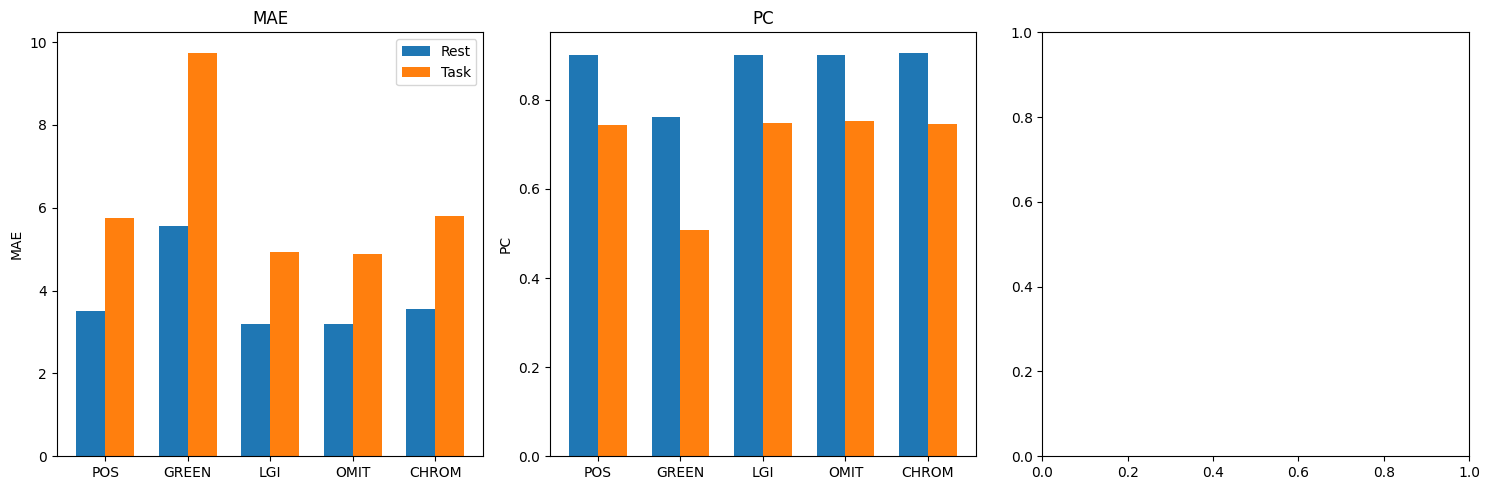

In [22]:
metrics = ["MAE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_hr[eval_df_hr["Condition"]=="Rest"][metric]
    task_vals = eval_df_hr[eval_df_hr["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 4.4375     | 7.335700    | 0.890876  | 6.8125     | 9.775607    | 0.667658  |
| GREEN  | 7.8750     |10.191909    | 0.698441  |10.2500     |13.697628    | 0.250453  |
| LGI    | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.695346    | 0.321868  |
| OMIT   | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.736357    | 0.322018  |
| CHROM  | 4.1250     | 6.698881    | 0.908825  | 7.1875     | 9.450529    | 0.600982  |

**Observation**

---

- Pada kondisi istirahat, rPPG dapat mengukur HR (detak jantung) dengan cukup stabil dan konsistensi yang tinggi terhadap hasil HR dari PPG, dengan nilai MAE < 5 (stabilitas) dan PC > 0.8 (konsistensi) baik.
- Sebaliknya, pada tugas mental, pengukuran HR (detak jantung) relatif kurang stabil dengan error yang meningkat (MAE dan RMSE lebih tinggi), dan korelasi (PC) yang menurun, menandakan reliabilitas rPPG berkurang dalam mengukur detak jantung (HR), karena pada tugas mental, tidak sepenuhnya subjek diam, penurunan performa ini kemungkinan disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi dibandingkan saat kondisi istirahat, dimana subjek relatif diam. 
- Secara umum, dalam studi biomedis, MAE < 5 bpm dan RMSE < 8 bpm dianggap cukup baik untuk estimasi HR dari video, serta PC > 0.8 (baik) dan > 0.6 (moderat) [[0]](https://biomedical-engineering-online.biomedcentral.com/articles/10.1186/s12938-025-01405-5?utm_source=chatgpt.com).
- Dari hasil evaluasi, metode POS dan CHROM terbukti paling robust di kedua skenario (Rest dan Task), dengan error rendah dan konsistensi tren pengukuran HR terhadap PPG (PC > 0.6, kategori moderat hingga baik).

#### Ekstraksi HRV (SDNN)

temporary data

In [23]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Istirahat' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Tugas Mental' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_sdnn = pd.DataFrame(rows, columns=columns)
print("SDNN (Satuan: ms)")
df_sdnn


SDNN (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   48   53    86   57   56    59  160   66   161   72   68    72
1      s42   86   88   144   88   87   125  107  112   146  126  126   128
2      s43   32   38    80   56   56    45   89   93   152  102  101   100
3      s44  111  149   140  121  122   148  129  126   147  116  117   154
4      s45   73   62   143   63   63    98   80   92   135  105  104   112
5      s46   59   59    67   58   59    76   78   96   142  109  105   100
6      s47   70   72    90   78   79    92  150   77   209   99  106    90
7      s48  165   71   115   79   78    97  147  129   155  126  137   130
8      s49   39   42    91   56   56    45  155   95   146  113  119    98
9      s50   28   38   101   38   38    49   45   52   127   55   56    56
10     s51   70   75   133   71   71   109  109   99   178  105  104   126
11     s52  194   93   125   97   97    90  135   99   157  107  106   104
12     s53  110  140   152  141  141   149  148  113   149  107  107   120
13     s54   75   49   115   62   63    52   58   78   153  102  102    86
14     s55   83   82   191   87   89    92   90  104   157  107  111   118
15     s56  152   83   158   89   84   104  123  111   154  114  114   123

In [24]:
# Convert to latex
df_sdnn.to_latex("sdnn_results_table.tex", index=False)

#### Evaluasi SDNN (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai SDNN antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran SDNN dari rPPG dan PPG.

In [25]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_sdnn[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_sdnn[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            # "RMSE": rmse,
            "PC": pc
        })

eval_df_sdnn = pd.DataFrame(eval_results)
eval_df_sdnn

,Condition,Method,MAE,PC
0,Rest,POS,25.1875,0.555305
1,Rest,GREEN,48.3750,0.455541
2,Rest,LGI,24.1250,0.618117
3,Rest,OMIT,24.5000,0.597125
4,Rest,CHROM,32.5625,0.524511
5,Task,POS,26.3125,0.370526
6,Task,GREEN,42.6875,0.469829
7,Task,LGI,28.5000,0.306163
8,Task,OMIT,27.2500,0.349991
9,Task,CHROM,29.7500,0.291551


**Visualisasi Hasil MAE, RMSE dan PC**

---

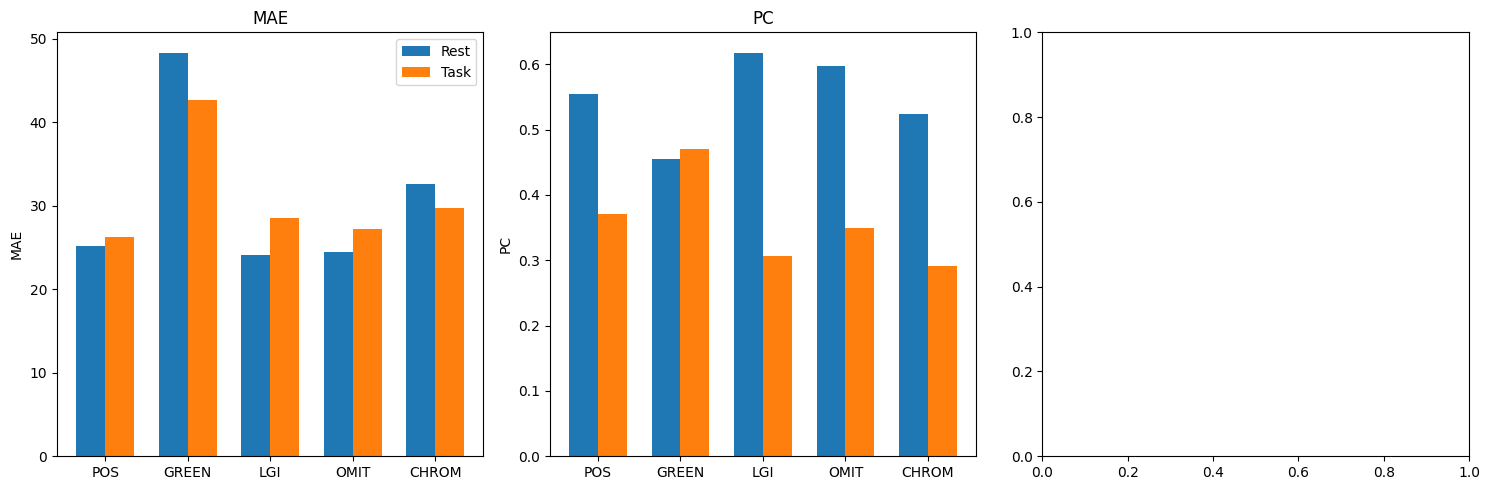

In [26]:
metrics = ["MAE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Rest"][metric]
    task_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 50.89      | 83.41       | 0.4546    | 70.89      | 95.17       | 0.2672    |
| GREEN  |113.42      |127.37       | 0.6198    | 94.20      |116.28       | 0.1734    |
| LGI    | 43.35      | 66.98       | 0.6697    | 69.93      | 80.68       | 0.3106    |
| OMIT   | 43.06      | 66.51       | 0.6768    | 69.84      | 81.59       | 0.2907    |
| CHROM  | 53.64      | 70.66       | 0.5486    | 72.87      | 86.82       | -0.0077   |

**Observation**

---

- HRV adalah ukuran variasi waktu antar detak jantung, sehingga membutuhkan ketelitian waktu yang lebih tinggi dibandingkan hanya menghitung rata-rata detak jantung (HR).

- Dalam evaluasi, HRV (misal SDNN) menunjukkan seberapa besar fluktuasi interval antar detak, bukan hanya jumlah detak per menit. Oleh karena itu, kualitas sinyal dan akurasi deteksi puncak sangat penting agar hasil HRV

- Pengukuran HRV seperti ini biasanya menggunakan metode kontak (EKG / PPG) yang memiliki error yang lebih rendah (MAE < 10ms) yang cocok dipakai.

- rPPG sebagai metode kontak tentu akan menghadapi error tambahan seperti delay, noise, dan aftifak gerakan. Penelitian sebelumnya berfokus pada pengukuran HRV melaporkan error SDNN / RMSSD 10 - 40 ms (Perbedaan dengan metode kontak PPG) [[1]](https://www.mdpi.com/2306-5354/10/7/851)[[2]](https://arxiv.org/pdf/2305.04161). Penggunaan korelasi (PC) juga digunakan untuk menilai konsistensi pengukuran SDNN ini.

- Pada kondisi istirahat, sama seperti pengukuran detak jantung, beberapa metode rPPG masih dapat mencapai korelasi moderat (PC > 0.6), meskipun MAE relatif tinggi (> 30–40 ms). Hal ini menunjukan rPPG dapat melakukan pengukuran HRV meskipun cederung overestimasi (dengan error yang relatif tinggi).

- Kondisi tugas/mental load: performa memburuk lebih jauh (MAE/RMSE meningkat, PC < 0.3), sehingga estimasi HRV tidak konsisten dengan referensi kontak. Penurunan performa ini disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi sama seperti pengukuran HR

- Kesimpulan: saat ini, rPPG belum cukup andal untuk mengukur nilai absolut HRV (seperti SDNN) di berbagai kondisi. Namun, pada skenario minim gerakan, rPPG masih bisa digunakan untuk memantau tren relatif (apakah HRV naik/turun) dibandingkan ground truth. Untuk mencapai presisi yang mendekati metode kontak, diperlukan pendekatan rekonstruksi sinyal yang lebih canggih 

- Namun secara general rPPG masih belum bisa untuk menangkap detail variabilitas detak jantung yang membutuhkan presisi tingkat lanjut serta reliabilitas yang masih kurang (Pearson Corr yang lemah)

#### Ekstraksi HRV (RMSSD)

---

In [27]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Istirahat' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'Tugas Mental' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_rmssd = pd.DataFrame(rows, columns=columns)
print("RMSSD (Satuan: ms)")
df_rmssd

RMSSD (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   44   50   115   62   61    66  182   82   186   94   87    99
1      s42   82   84   171   78   78   166  142  147   184  169  172   161
2      s43   34   48   123   83   83    64  113  129   213  150  149   135
3      s44   88  157   180  143  141   196  146  157   186  137  143   192
4      s45   94   81   180   81   80   151  112  142   182  160  158   171
5      s46   58   62    74   59   60   100   80  113   174  150  141   131
6      s47   60   68   122   94   96   122  198   86   222  119  129   105
7      s48  220   79   174   95   94   144  178  141   177  159  168   145
8      s49   37   39   116   74   74    46  191  117   183  145  155   132
9      s50   20   46   148   49   49    68   51   73   154   80   81    79
10     s51   79   88   169   76   76   147  144  136   238  146  143   182
11     s52   94  107   164  119  119   118  172  119   177  130  127   144
12     s53  147   80   150   85   85   116  178  133   176  130  129   166
13     s54  100   73   150   93   93    79   81  108   187  141  140   131
14     s55   99   87   196   95   93   110   85  123   195  133  131   151
15     s56  188  109   192  114  112   140  171  153   207  160  159   160

In [28]:
# Export to latex
df_rmssd.to_latex("rmssd_results_table.tex", index=False)

In [29]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_rmssd[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_rmssd[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            # "RMSE": rmse,
            "PC": pc
        })

eval_df_rmssd = pd.DataFrame(eval_results)
eval_df_rmssd

,Condition,Method,MAE,PC
0,Rest,POS,30.7500,0.465449
1,Rest,GREEN,67.0000,0.569889
2,Rest,LGI,33.7500,0.478555
3,Rest,OMIT,34.1250,0.467637
4,Rest,CHROM,46.3125,0.504451
5,Task,POS,39.3125,0.184189
6,Task,GREEN,52.4375,0.294501
7,Task,LGI,41.4375,0.120867
8,Task,OMIT,39.2500,0.212469
9,Task,CHROM,43.6250,0.165408


**Visualisasi Hasil MAE, RMSE dan PC**

---

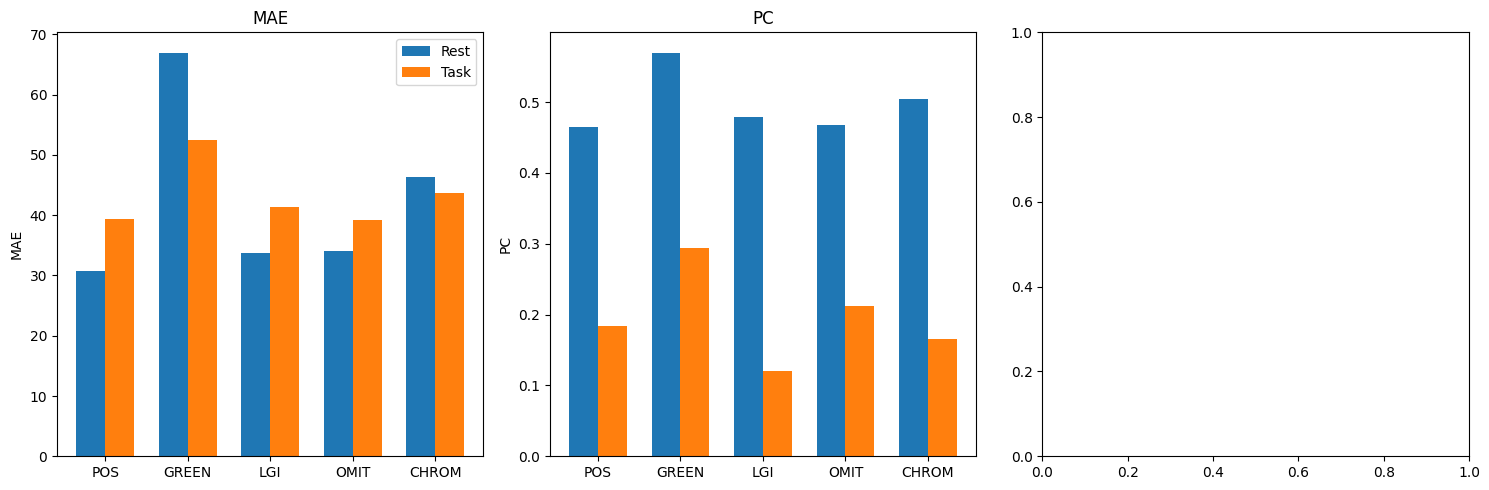

In [30]:
metrics = ["MAE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Rest"][metric]
    task_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 63.88      |104.86       | 0.5589    | 99.94      |130.87       | 0.2401    |
| GREEN  |159.25      |180.08       | 0.6639    |133.81      |160.21       | 0.0719    |
| LGI    | 51.94      | 80.50       | 0.7389    | 93.94      |109.39       | 0.3029    |
| OMIT   | 52.69      | 79.93       | 0.7521    | 94.13      |110.00       | 0.3005    |
| CHROM  | 74.00      | 90.42       | 0.5858    |106.00      |120.75       | -0.1035   |

**Observation**

---

- RMSSD adalah metrik HRV yang mengukur variasi jeda waktu antar detak jantung. Seperti SDNN, RMSSD membutuhkan ketelitian waktu tinggi karena fokusnya pada perubahan waktu antar detak, bukan hanya jumlah detak.
- Pada kondisi tugas mental, performa rPPG menurun, baik dari sisi error maupun konsistensi pola (Pearson Correlation).
- Secara umum, rPPG kurang cocok untuk mengukur HRV secara non-kontak di berbagai skenario karena sangat sensitif terhadap gerakan dan pencahayaan, sehingga presisi hasil HRV sulit

### Overall Checks: Visualisasi Hasil MAE, RMSE, dan PC

---

Evaluasi awal dilakukan untuk menilai sejauh mana metode rPPG mampu merekonstruksi sinyal fisiologis dibandingkan sinyal referensi PPG. Penilaian dilakukan pada dua skenario (Rest dan Task) dengan tiga metrik utama: HR, SDNN, dan RMSSD. Setiap metode rPPG dievaluasi menggunakan indikator statistik (MAE, RMSE, dan Pearson Correlation).

Hasil evaluasi ini menjadi dasar untuk:
1. Menentukan metode rPPG yang relatif paling konsisten pada kedua skenario.  
2. Mengidentifikasi metrik fisiologis yang lebih stabil untuk digunakan pada tahap analisis berikutnya.  

Secara umum, **HR menunjukkan kecenderungan lebih reliabel** dibanding SDNN dan RMSSD, dengan performa lebih baik pada MAE, RMSE, dan PC. Di antara metode rPPG, **POS dan CHROM tampil lebih konsisten terutama pada estimasi HR**, meskipun performa estimasi HRV masih bervariasi dan dari hasil pengukuran, error yang dihasilkan masih cukup tinggi untuk dapat digunakan sebagai alternatif.

Berdasarkan hal ini, analisis selanjutnya difokuskan pada **HR** sebagai metrik utama. Fokus ini tidak hanya karena keunggulan teknis (error lebih rendah), tetapi juga karena HR lebih relevan sebagai indikator fisiologis terhadap peningkatan beban mental. Dengan demikian, tahap berikutnya akan memvisualisasikan perbedaan antara kondisi Rest dan Task pada level kelompok maupun individu.


### Evaluation Metrics (Overall)

For method comparison, we employed two complementary metrics:

1. **Mean Absolute Error (MAE)**: Measures prediction accuracy by calculating the average absolute difference between rPPG estimates and PPG ground truth values.

2. **Pearson Correlation (PC)**: Evaluates how well rPPG methods capture the physiological trend patterns compared to ground truth, regardless of absolute value differences.

We focused on MAE and PC rather than including RMSE for the following reasons:
- **Reduced redundancy**: MAE and RMSE both measure prediction error, with RMSE being more sensitive to outliers. For ranking purposes, they provide similar method ordering.
- **Complementary information**: MAE quantifies accuracy while PC assesses pattern consistency, providing distinct evaluation perspectives.
- **Interpretability**: MAE offers direct clinical interpretation (error in bpm/ms), while PC indicates trend-following capability.
- **Simplicity**: A two-metric approach reduces complexity while maintaining comprehensive evaluation coverage.

In [31]:
# SIMPLIFIED COMPREHENSIVE RANKING ANALYSIS
print("="*80)
print("COMPREHENSIVE METHOD RANKING ANALYSIS")
print("="*80)

# Step 1: Calculate average metrics across conditions for each physiological metric
def calculate_metric_ranking(eval_df, metric_name):
    """Calculate ranking for a single physiological metric (HR, SDNN, or RMSSD)"""
    
    # Pivot to get Rest and Task values
    pivot = eval_df.pivot_table(index='Method', columns='Condition', values=['MAE', 'PC'])
    
    # Calculate averages across conditions
    mae_avg = (pivot[('MAE', 'Rest')] + pivot[('MAE', 'Task')]) / 2
    pc_avg = (pivot[('PC', 'Rest')] + pivot[('PC', 'Task')]) / 2
    
    # Rank metrics (1 = best)
    mae_rank = mae_avg.rank(ascending=True)   # Lower MAE is better
    pc_rank = pc_avg.rank(ascending=False)    # Higher PC is better
    
    # Calculate average rank for this metric
    metric_avg_rank = (mae_rank + pc_rank) / 2
    
    print(f"\n{metric_name.upper()} RANKING:")
    print("-" * 50)
    print(f"{'Method':<8} {'MAE_avg':<8} {'Rank':<6} {'PC_avg':<8} {'Rank':<6} {'Avg_Rank':<8}")
    print("-" * 50)
    
    # Sort by average rank and display
    sorted_methods = metric_avg_rank.sort_values()
    for method in sorted_methods.index:
        star = " ★" if method == sorted_methods.index[0] else ""
        print(f"{method:<8} {mae_avg[method]:<8.2f} {mae_rank[method]:<6.0f} {pc_avg[method]:<8.3f} {pc_rank[method]:<6.0f} {sorted_methods[method]:<8.2f}{star}")
    
    return metric_avg_rank

# Step 2: Calculate rankings for each physiological metric
hr_ranks = calculate_metric_ranking(eval_df_hr, "HR")
sdnn_ranks = calculate_metric_ranking(eval_df_sdnn, "SDNN") 
rmssd_ranks = calculate_metric_ranking(eval_df_rmssd, "RMSSD")

# Step 3: Calculate final overall ranking
print(f"\n{'='*80}")
print("FINAL OVERALL RANKING")
print("="*80)

methods = hr_ranks.index.tolist()
final_ranks = {}

for method in methods:
    # Average of the three metric rankings
    overall_rank = (hr_ranks[method] + sdnn_ranks[method] + rmssd_ranks[method]) / 3
    final_ranks[method] = overall_rank

# Sort by final rank
final_ranking = sorted(final_ranks.items(), key=lambda x: x[1])

print(f"{'Method':<8} {'HR_Rank':<8} {'SDNN_Rank':<10} {'RMSSD_Rank':<11} {'Overall_Rank':<12}")
print("-" * 60)

for i, (method, overall_rank) in enumerate(final_ranking):
    star = " ★★★" if i == 0 else ""
    print(f"{method:<8} {hr_ranks[method]:<8.2f} {sdnn_ranks[method]:<10.2f} {rmssd_ranks[method]:<11.2f} {overall_rank:<12.2f}{star}")

print(f"\nFINAL CALCULATION:")
print("-" * 40)
for method, overall_rank in final_ranking:
    print(f"{method}: ({hr_ranks[method]:.2f} + {sdnn_ranks[method]:.2f} + {rmssd_ranks[method]:.2f}) / 3 = {overall_rank:.2f}")

winner = final_ranking[0][0]
print(f"\n🏆 WINNER: {winner} (Overall Rank = {final_ranking[0][1]:.2f})")

COMPREHENSIVE METHOD RANKING ANALYSIS

HR RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
--------------------------------------------------
OMIT     4.03     1      0.826    1      1.00     ★
LGI      4.06     2      0.825    3      2.50    
CHROM    4.69     4      0.826    2      3.00    
POS      4.62     3      0.821    4      3.50    
GREEN    7.66     5      0.635    5      5.00    

SDNN RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
--------------------------------------------------
OMIT     25.88    2      0.474    1      1.50     ★
POS      25.75    1      0.463    2      1.50    
LGI      26.31    3      0.462    4      3.50    
GREEN    45.53    5      0.463    3      4.00    
CHROM    31.16    4      0.408    5      4.50    

RMSSD RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
---------

## Analisis : Tugas Istirahat vs Tugas Mental

---

Analisis perbandingan kondisi istirahat (Rest) dan tugas mental (Task) difokuskan pada dua metrik utama, yaitu HR (Heart Rate) dan HRV (Heart Rate Variability). Dari hasil evaluasi, HR merupakan metrik yang paling reliabel untuk diestimasi menggunakan rPPG, sehingga interpretasi utama akan menekankan pada perubahan HR antar kondisi. 

Sementara itu, HRV juga tetap ditampilkan untuk memberikan gambaran pola fisiologis yang lebih lengkap, meskipun hasil estimasi dengan rPPG menunjukkan variasi yang lebih tinggi dan konsistensinya lebih rendah dibandingkan PPG. 

Visualisasi berikut akan menunjukkan bagaimana perubahan HR terjadi antara kondisi Rest dan Task, baik pada level kelompok maupun individu, serta ringkasan perubahan HRV yang diamati.

---


### Analisis Tingkat Kelompok

Melihat pengaruh kondisi tugas terhadap peningkatan HR secara keseluruhan pada kelompok subjek.

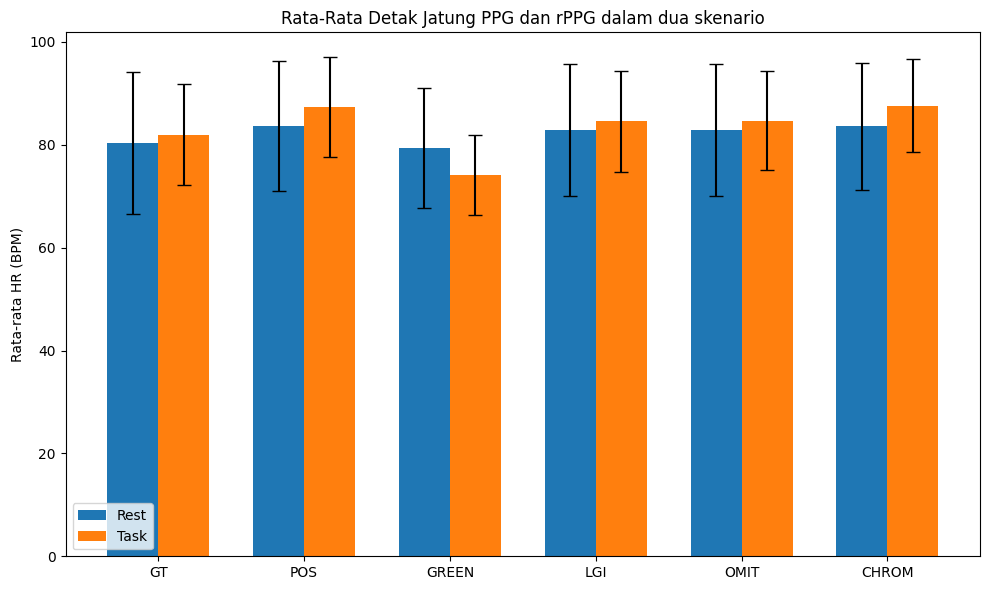

In [32]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_hr[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Rata-rata HR (BPM)")
ax.set_title("Rata-Rata Detak Jatung PPG dan rPPG dalam dua skenario")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_hr[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,80.3125,14.206659,81.9375,10.135540
POS,83.6875,13.036967,87.3125,10.031409
GREEN,79.3750,12.010412,74.0625,8.053726
LGI,82.8750,13.200379,84.6250,10.131634
OMIT,82.8750,13.200379,84.6875,9.978101
CHROM,83.6250,12.732504,87.6250,9.294263


**Observasi dan Analisis**

---

- Berdasarkan data rata-rata (mean) dan standar deviasi (STD) detak jantung dari metode kontak (PPG/GT), tidak ditemukan perbedaan signifikan antara kondisi istirahat (Rest) dan tugas mental (Task). Nilai rata-rata HR hampir sama (Rest: 79.44 bpm, Task: 79.25 bpm).

- Studi lebih lanjut dengan jumlah data yang lebih besar diperlukan agar efek statistik dapat terlihat lebih jelas.

- Metode rPPG cenderung menghasilkan estimasi pengukuran HR yang lebih tinggi (overestimasi) atau lebih rendah (underestimasi) dibandingkan GT, dengan rata-rata HR yang relatif tinggi pada kedua skenario.

- Karena secara statistik belum terlihat perbedaan yang jelas, analisis intrasubjek diperlukan untuk mengetahui apakah PPG dan rPPG mampu menangkap perubahan fisiologis individu saat mengalami beban mental.

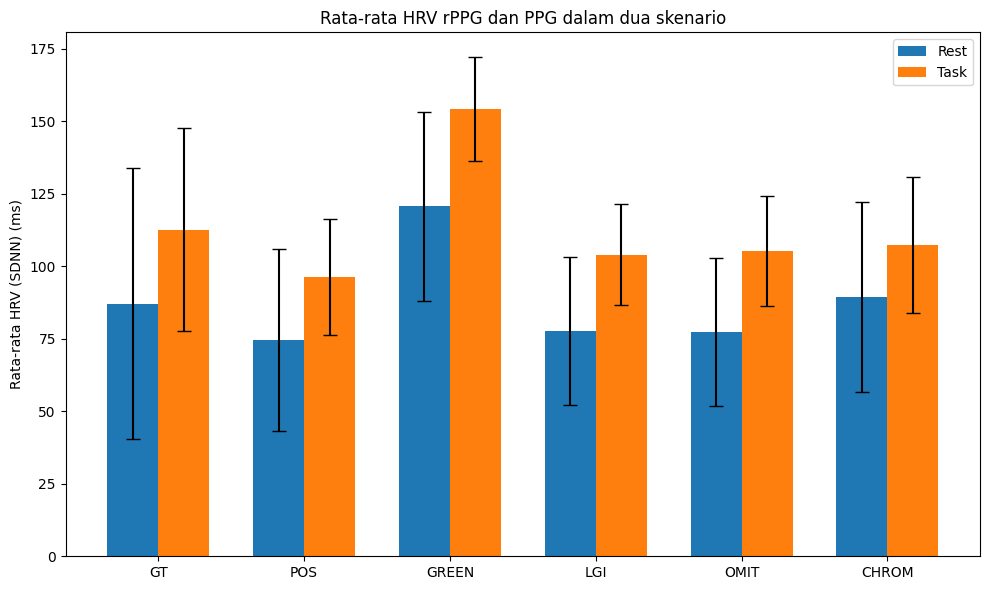

In [34]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_sdnn[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Rata-rata HRV (SDNN) (ms)")
ax.set_title("Rata-rata HRV rPPG dan PPG dalam dua skenario")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_sdnn[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,87.1875,48.244127,112.6875,36.222863
POS,74.6250,32.395216,96.3750,20.632903
GREEN,120.6875,33.583168,154.2500,18.455352
LGI,77.5625,26.353921,104.0625,17.897742
OMIT,77.4375,26.346331,105.1875,19.535331
CHROM,89.3750,33.737961,107.3125,24.294632


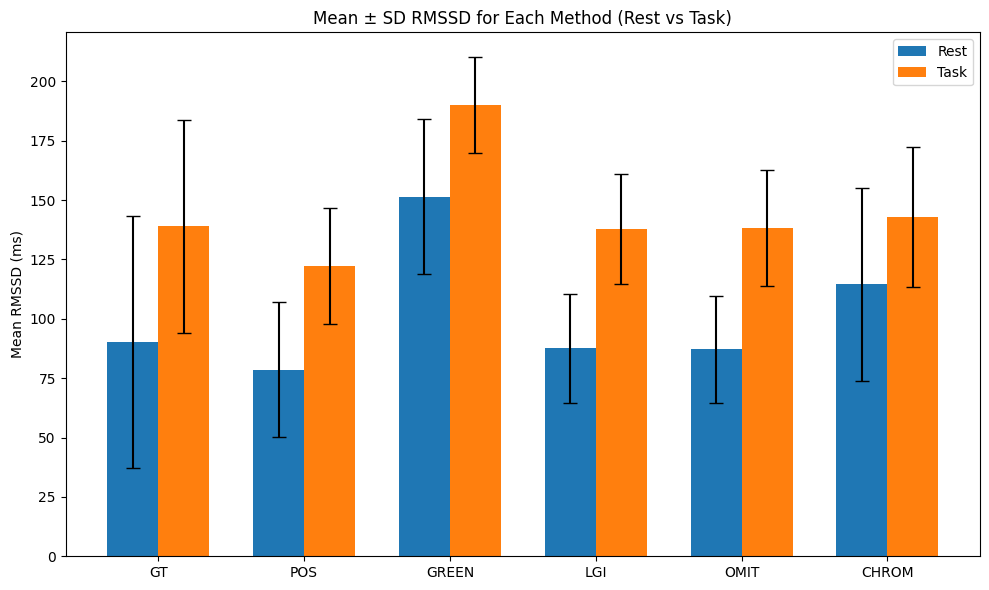

In [36]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_rmssd[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Mean RMSSD (ms)")
ax.set_title("Mean ± SD RMSSD for Each Method (Rest vs Task)")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_rmssd[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,90.2500,54.795985,139.0000,46.319182
POS,78.6250,29.300455,122.4375,25.224244
GREEN,151.5000,33.557910,190.0625,20.731518
LGI,87.5000,23.633310,137.6875,23.935242
OMIT,87.1250,23.174339,138.2500,25.233576
CHROM,114.5625,42.049128,142.7500,30.402851


**Notes**

Hasil perhitungan HRV (SDNN/RMSSD) menunjukkan bahwa nilai HRV justru meningkat pada kondisi Task dibandingkan Rest, baik pada data GT maupun sebagian metode rPPG. Pola ini berbeda dengan teori psikofisiologi, yang biasanya memperkirakan HRV menurun saat beban mental meningkat. Perbedaan ini kemungkinan muncul karena durasi tugas yang singkat, perbedaan respons tiap individu, atau adanya noise pada estimasi HRV dari rPPG.

Dibutuhkan analisis intrasubjek untuk melihat efek ini lebih dekat


### Analisis Intrasubjek

Melihat bagaimana Respons Individu terhadap Pengaruh tugas istirahat dan mental

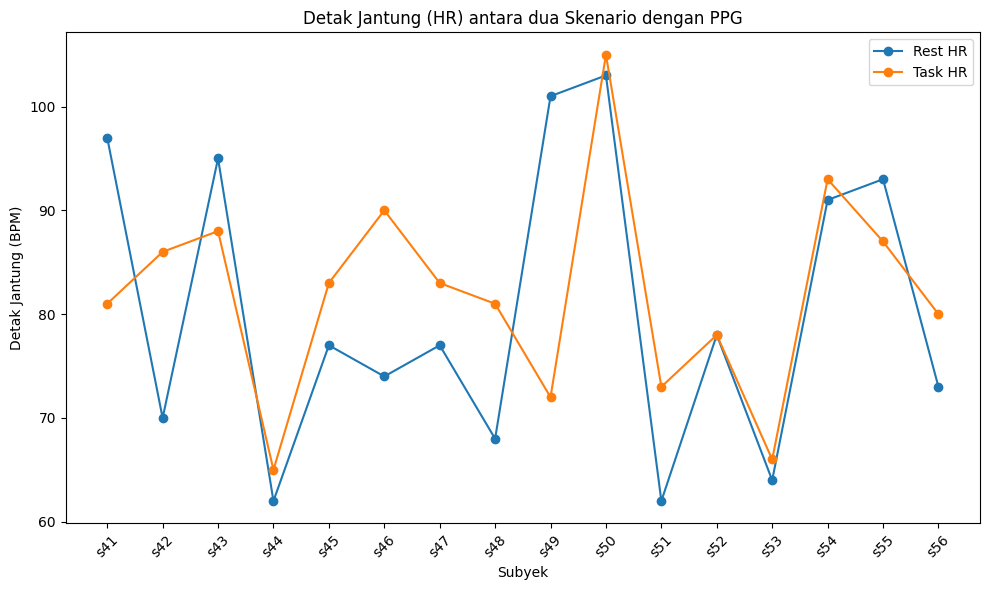

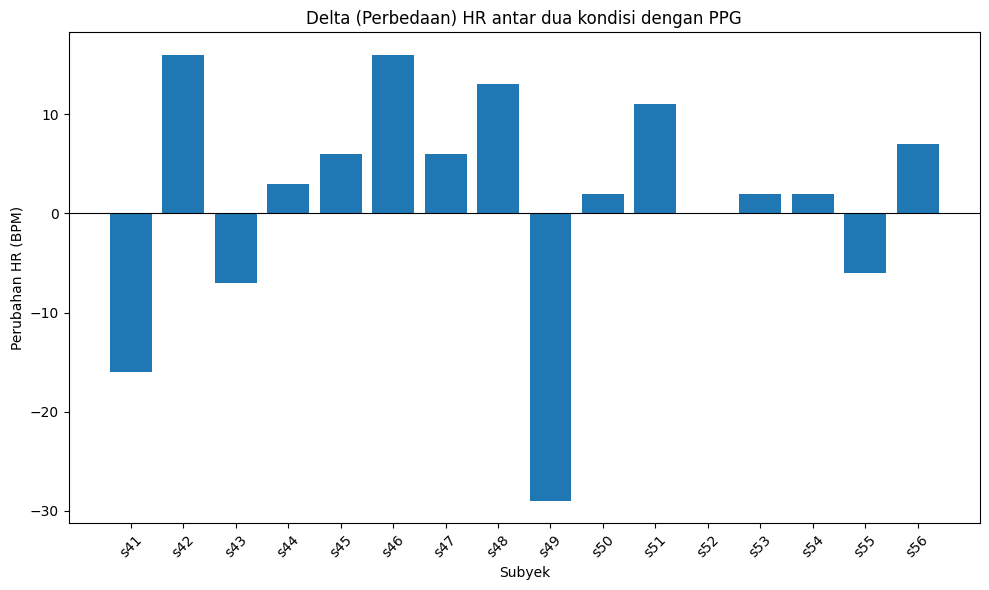

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,97,81,-16
1,s42,70,86,16
2,s43,95,88,-7
3,s44,62,65,3
4,s45,77,83,6
5,s46,74,90,16
6,s47,77,83,6
7,s48,68,81,13
8,s49,101,72,-29
9,s50,103,105,2


In [38]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "GT")].values
task_hr = df_hr[("Task", "GT")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_hr,
    "Task_GT": task_hr,
    "Delta_GT": delta_hr
})

fig = plt.figure(figsize=(10, 6))

## Line Chart
plt.plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HR")
plt.plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HR")
plt.title("Detak Jantung (HR) antara dua Skenario dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Detak Jantung (BPM)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_GT"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Delta (Perbedaan) HR antar dua kondisi dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Perubahan HR (BPM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

**Metode POS**

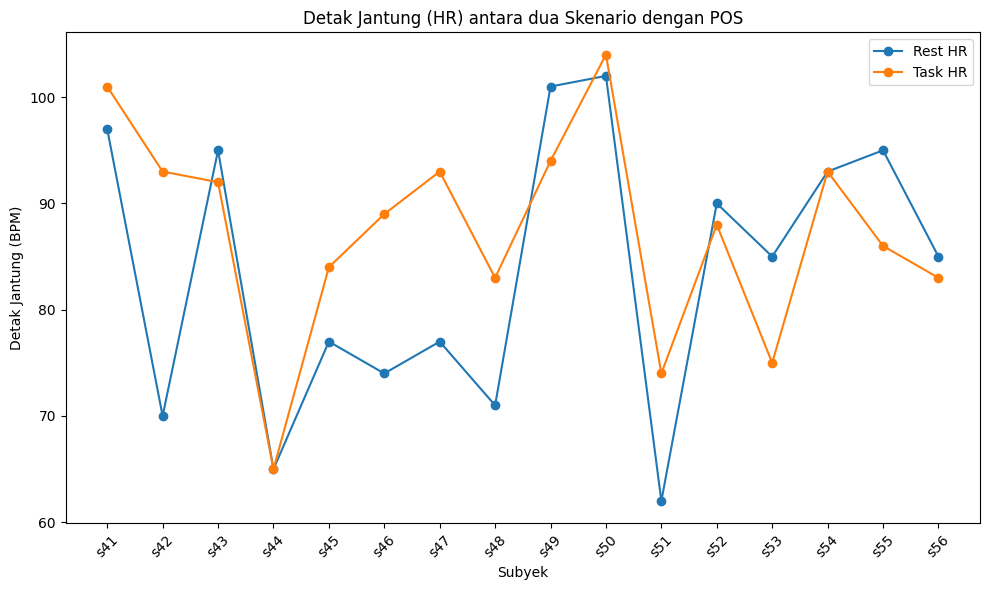

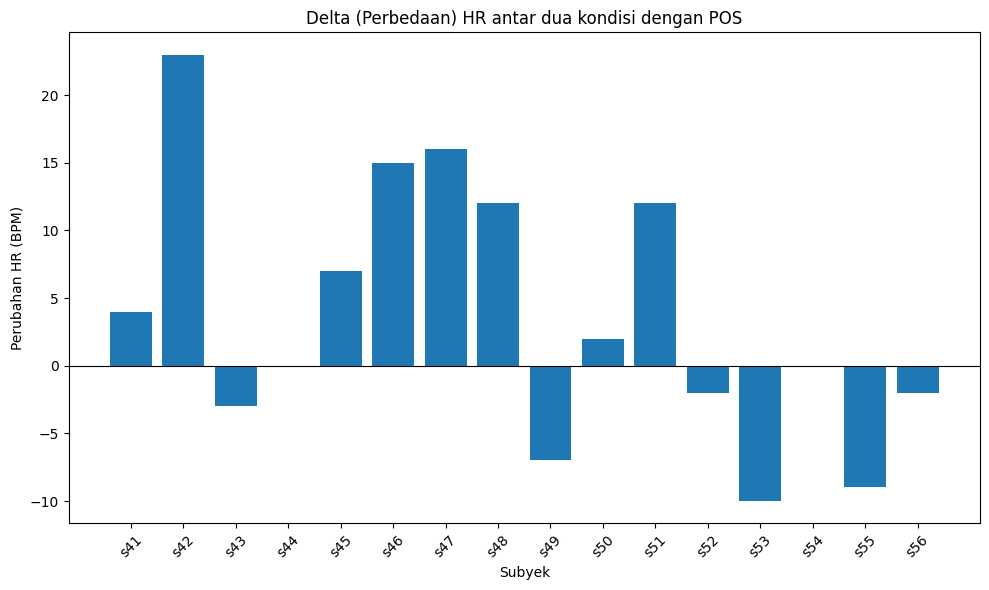

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,97,101,4
1,s42,70,93,23
2,s43,95,92,-3
3,s44,65,65,0
4,s45,77,84,7
5,s46,74,89,15
6,s47,77,93,16
7,s48,71,83,12
8,s49,101,94,-7
9,s50,102,104,2


In [39]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "POS")].values
task_hr = df_hr[("Task", "POS")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_hr,
    "Task_POS": task_hr,
    "Delta_POS": delta_hr
})


## Line Chart
plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HR")
plt.plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HR")
plt.title("Detak Jantung (HR) antara dua Skenario dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Detak Jantung (BPM)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_POS"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Delta (Perbedaan) HR antar dua kondisi dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Perubahan HR (BPM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Metode CHROM**

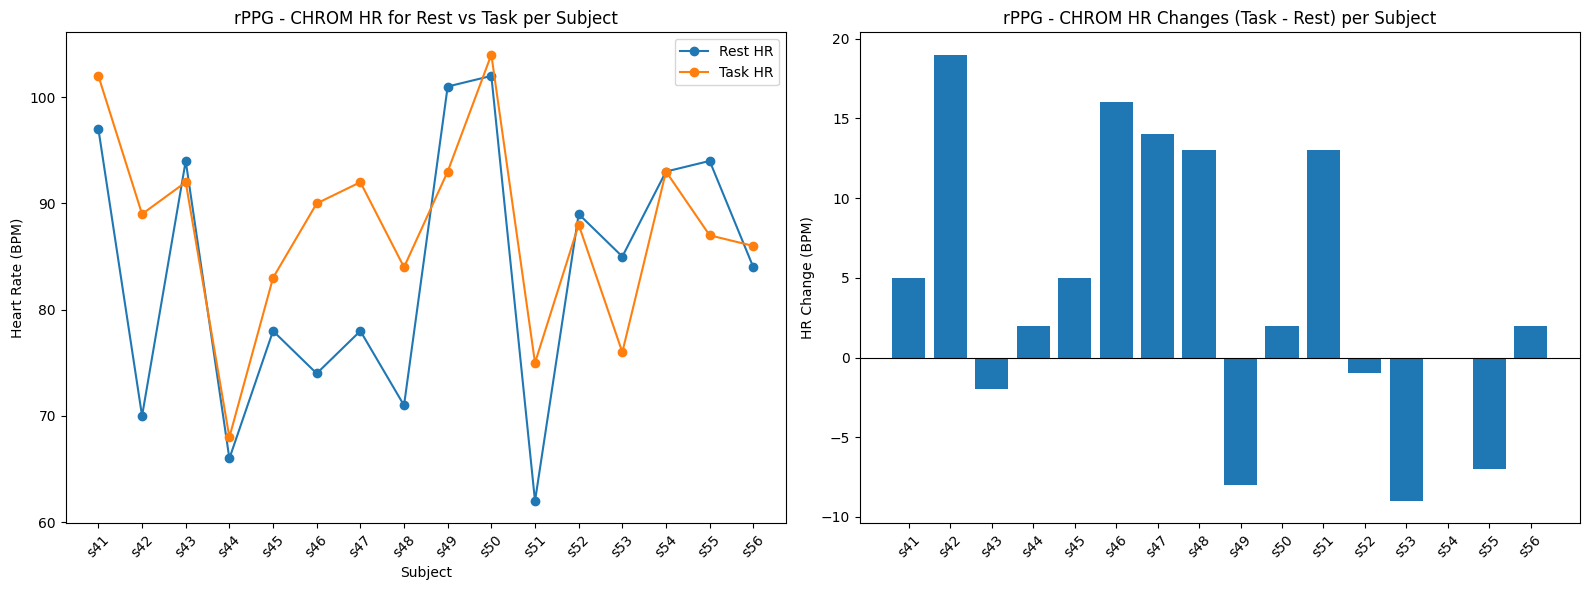

,Subject,Rest_CHROM,Task_CHROM,Delta_CHROM
0,s41,97,102,5
1,s42,70,89,19
2,s43,94,92,-2
3,s44,66,68,2
4,s45,78,83,5
5,s46,74,90,16
6,s47,78,92,14
7,s48,71,84,13
8,s49,101,93,-8
9,s50,102,104,2


In [40]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "CHROM")].values
task_hr = df_hr[("Task", "CHROM")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_CHROM": rest_hr,
    "Task_CHROM": task_hr,
    "Delta_CHROM": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_CHROM"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_CHROM"], marker="o", label="Task HR")
axes[0].set_title("rPPG - CHROM HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_CHROM"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - CHROM HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_CHROM","Task_CHROM","Delta_CHROM"]]

### Konsistensi Pola antara GT & rPPG

- Secara individu, baik data PPG maupun rPPG saat mengukur HR (detak jantung) menunjukkan variasi respons yang berbeda ketika subjek berada dalam beban mental.

- Sebagian subjek mengalami peningkatan detak jantung, sementara yang lain mengalami penurunan, baik pada plot data HR menggunakan metode kontak (PPG) maupun non-kontak (rPPG, POS dan CHROM) yang relatif stabil terhadap tugas mental.

- Hal ini mendukung teori psikofisiologis bahwa respons individu terhadap beban mental memang bervariasi secara fisiologis, namun diperlukan data lebih banyak agar efek statistik dapat terlihat lebih

### HRV

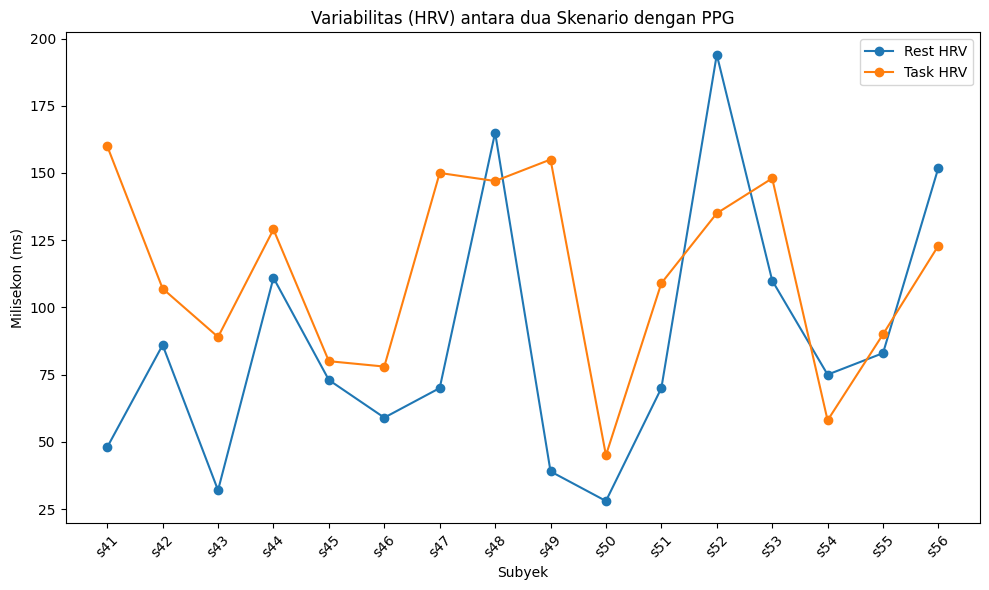

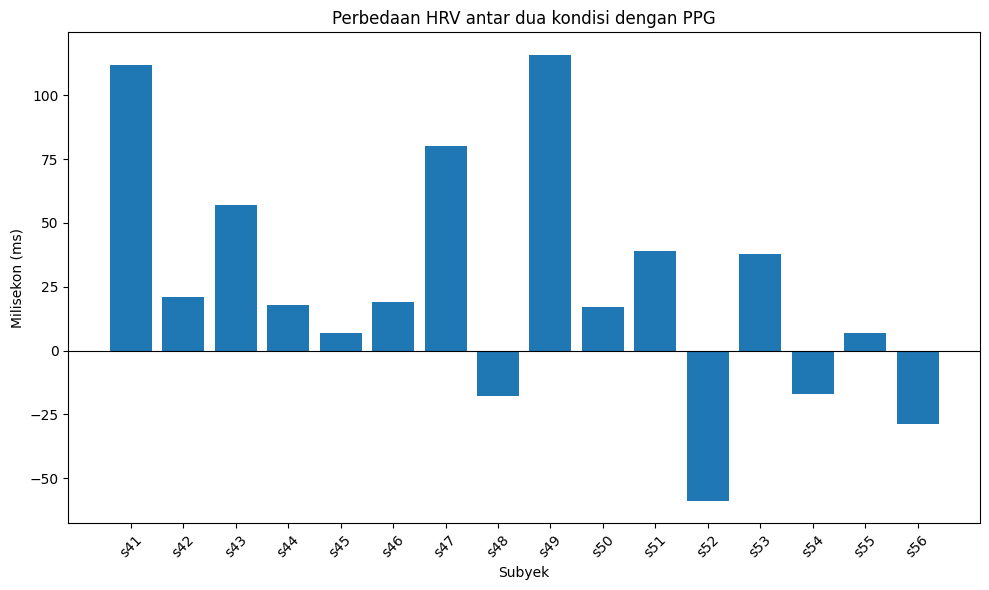

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,48,160,112
1,s42,86,107,21
2,s43,32,89,57
3,s44,111,129,18
4,s45,73,80,7
5,s46,59,78,19
6,s47,70,150,80
7,s48,165,147,-18
8,s49,39,155,116
9,s50,28,45,17


In [41]:
subjects = df_sdnn[("", "Subject")].values if ("", "Subject") in df_sdnn.columns else df_sdnn.index
rest_sdnn = df_sdnn[("Rest", "GT")].values
task_sdnn = df_sdnn[("Task", "GT")].values
delta_sdnn = task_sdnn - rest_sdnn

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_sdnn,
    "Task_GT": task_sdnn,
    "Delta_GT": delta_sdnn
})

## Line Chart
plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HRV")
plt.plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HRV")
plt.title("Variabilitas (HRV) antara dua Skenario dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_GT"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Perbedaan HRV antar dua kondisi dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Line chart
# axes[0].plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HRV")
# axes[0].plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HRV")
# axes[0].set_title("GT HRV for Rest vs Task per Subject")
# axes[0].set_xlabel("Subject")
# axes[0].set_ylabel("HRV")
# axes[0].legend()
# axes[0].tick_params(axis='x', rotation=45)

# # Bar chart
# axes[1].bar(df_ind["Subject"], df_ind["Delta_GT"])
# axes[1].axhline(0, color="black", linewidth=0.8)
# axes[1].set_title("GT HR Changes (Task - Rest) per Subject")
# axes[1].set_ylabel("HRV")
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

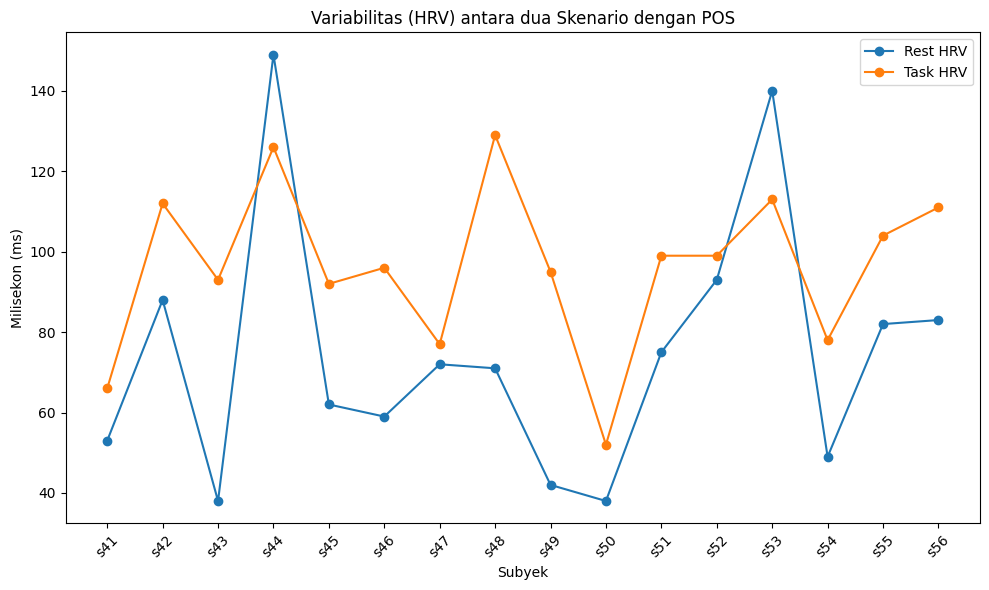

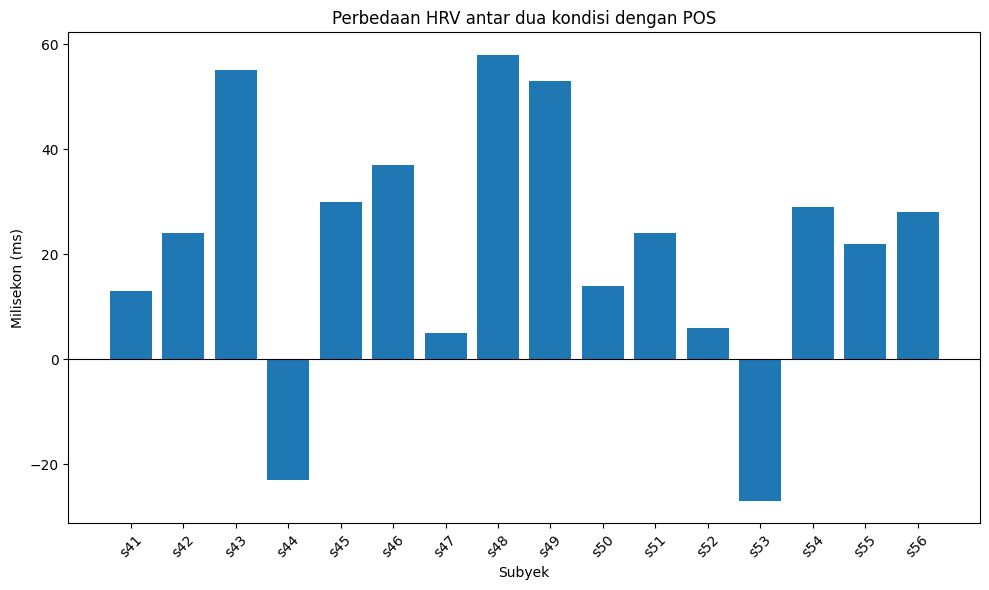

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,53,66,13
1,s42,88,112,24
2,s43,38,93,55
3,s44,149,126,-23
4,s45,62,92,30
5,s46,59,96,37
6,s47,72,77,5
7,s48,71,129,58
8,s49,42,95,53
9,s50,38,52,14


In [42]:
subjects = df_sdnn[("", "Subject")].values if ("", "Subject") in df_sdnn.columns else df_sdnn.index
rest_sdnn = df_sdnn[("Rest", "POS")].values
task_sdnn = df_sdnn[("Task", "POS")].values
delta_sdnn = task_sdnn - rest_sdnn

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_sdnn,
    "Task_POS": task_sdnn,
    "Delta_POS": delta_sdnn
})

plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HRV")
plt.plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HRV")
plt.title("Variabilitas (HRV) antara dua Skenario dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_POS"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Perbedaan HRV antar dua kondisi dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Notes**

Menariknya, hasil HRV pada penelitian ini menunjukkan tren peningkatan pada kondisi Task dibanding Rest, baik pada GT maupun estimasi rPPG. Pola ini bertentangan dengan temuan psikofisiologi yang umumnya melaporkan penurunan HRV ketika beban kognitif meningkat. Ketidaksesuaian ini dapat disebabkan oleh beberapa faktor, antara lain variasi individual dalam merespons tugas, karakteristik durasi dan tingkat kesulitan task yang digunakan, serta sensitivitas HRV terhadap noise pada sinyal rPPG. Dengan demikian, HRV dalam penelitian ini perlu ditafsirkan secara hati-hati, dan lebih tepat dianggap sebagai indikator eksploratif daripada konklusif.


## Diskusi Keseluruhan

---

### Implikasi terhadap beban mental

Berdasarkan hasil analisis HR pada kondisi istirahat dan tugas mental, secara umum terlihat adanya kecenderungan peningkatan detak jantung saat subjek menghadapi beban kognitif, meskipun respons intrasubjek menunjukkan variasi. Temuan ini mendukung teori psikofisiologis bahwa peningkatan beban mental berkaitan dengan peningkatan aktivasi fisiologis.

Namun, karena penelitian ini melibatkan jumlah subjek yang terbatas (N = 16), generalisasi hasil masih perlu diuji pada populasi yang lebih luas dan dengan variasi tugas kognitif yang berbeda. Penelitian lanjutan juga penting untuk mengeksplorasi kombinasi metrik lain seperti HRV, agar pemahaman mengenai respons fisiologis terhadap stres kognitif menjadi lebih komprehensif.

Hasil HRV (SDNN dan RMSSD) dari data GT menunjukkan adanya peningkatan nilai HRV pada kondisi Task dibanding Rest. Tren serupa juga terlihat pada beberapa metode rPPG (POS, LGI, OMIT, CHROM), meskipun skalanya berbeda dan tidak konsisten di seluruh subjek.

Temuan ini tidak sepenuhnya sejalan dengan literatur psikofisiologi, yang umumnya melaporkan penurunan HRV ketika beban kognitif meningkat. Perbedaan pola ini dapat disebabkan oleh beberapa faktor, seperti:

Variasi individual: sebagian partisipan mungkin merespons tugas dengan peningkatan aktivasi parasimpatis atau engagement, bukan stres.

Durasi dan desain tugas: beban kognitif yang relatif singkat atau kurang menantang bisa menghasilkan respons yang berbeda dari studi stres mental klasik.

Keterbatasan metode rPPG: estimasi HRV sangat sensitif terhadap noise sinyal, sehingga fluktuasi kecil dapat menghasilkan perbedaan arah tren.

### Keterbatasan metode rPPG

Metode rPPG menawarkan keunggulan karena mampu mengukur sinyal fisiologis hanya dengan kamera, tanpa sensor kontak langsung. Namun, penerapannya masih menghadapi beberapa keterbatasan.

Pertama, rPPG sangat sensitif terhadap pergerakan. Kondisi ideal ketika subjek benar-benar diam tidak selalu dapat dicapai, bahkan dalam lingkungan kerja yang terkontrol. Hal ini dapat memengaruhi akurasi estimasi detak jantung. Hal ini dibuktikan ketika terdapat penurunan error yang lebih tinggi ketika mengukur subjek dalam tugas mental

Kedua, rPPG memiliki keterbatasan dalam mengukur metrik psikofisiologis yang lebih kompleks seperti HRV. Estimasi HRV menuntut presisi tinggi dan stabilitas sinyal, sementara rPPG masih rentan terhadap noise, sehingga hasilnya kurang konsisten dibandingkan dengan sensor kontak langsung seperti PPG atau ECG.

### Konsep PoC

Berdasarkan hasil ini, akan dibuat sebuah PoC dengan menggunakan metode POS / CHROM karena metode ini masih cukup tahan (robust) pada dua kondisi yang berbeda sehingga cocok untuk melakukan monitoring terhadap individu.